# Analiza in napoved kriminalitete v slovenskih občinah

# Uvod

Cilj tega projekta je iz podatkov o kriminaliteti po Sloveniji zgraditi modele, ki pomagajo razumeti vzorce kaznivih dejanj in omogočajo osnovno napovedovanje tveganja za posamezne upravne enote. Osrednji cilj je regresijski ali klasifikacijski model, ki oceni verjetnost in obseg kriminalitete v posameznem letu, hkrati pa raziskuje vpliv demografskih in socialnih dejavnikov.

Osnovni dataset vsebuje število kaznivih dejanj po upravnih enotah in letih, razdeljeno po kategorijah (npr. tatvine, nasilje, premoženjska kriminaliteta). Ker podatki iz policijskih evidenc sami po sebi ne nudijo dovolj informacij za podrobno analizo, jih nadgradimo z:  

- demografskimi podatki (prebivalstvo, spol, starostne skupine, državljanstvo) iz SURS-a  
- podatki o izobrazbi in drugih socialno-ekonomskih značilnostih prebivalstva  
- združevanjem podatkov po upravnih enotah, da omogočimo primerjave med regijami  

V tem projektu so prikazani vsi koraki analize:  

1. čiščenje in priprava podatkov (odstranjevanje manjkajočih in neznanih vrednosti, standardizacija imen občin)  
2. združevanje podatkov iz različnih virov na ravni upravnih enot in let  
3. analiza časovnih trendov in prostorskih razlik v kriminaliteti  
4. vizualizacije za boljše razumevanje vzorcev  
5. regresijski in klasifikacijski pristopi za napovedovanje števila kaznivih dejanj  
6. interpretacija rezultatov in priporočila za nadaljnje raziskave ali uporabo modelov  

**Pomembna omejitev:** modeli temeljijo le na evidentiranih kaznivih dejanjih, zato napovedi odražajo verjetnost in obseg prijavljenih oziroma zaznanih primerov kriminalitete, ne pa celotne populacije potencialnih kaznivih dejanj.


#IMPORTI

In [ ]:
import pandas as pd
import numpy as np
from functools import reduce
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



#PRIPRAVA IN ČIŠČENJE DATASET-OV


*OPOMBA*

V vseh datasetih manjkajo podatki za Ankaran leta 2014, saj je nova občinska uprava začela z delovanjem šele 1. januarja 2015, zato so podatki leta 2014 za Ankaran že šteti k podatkov za Koper.

### KRIMINALITETA
Podatki o kaznivih dejanjih so bili pridobljeni december 2025 s spletne strani
https://www.policija.si/o-slovenski-policiji/statistika/kriminaliteta
Uporabljeni so podatki številu kaznivih dejanj po upravnih enotah, v zadnjih 11 letih, oziroma od 2014 do 2024


*OPOMBA*

Prvoten plan projekta je bil napoved kriminalitete po slovenskih občinah ampak ker policija kazniva dejanja beleži zgolj po upravnih enotah sem vse podatke, ki so bili pridobljeni na nivoju občin, združil v upravne enote. Podatke o upravnih enotah in pripadajočih občinah sem pridobil na spletni strani
https://www.stat.si/Klasje/Klasje/Details/1476
in jih potem preuredil v excel tablo "ue_obcine.xlsx"


Preberemo in združimo vse datoteke, hkrati pa preverimo, če imamo kaj manjkajočih podatkov za nam relevantne lastnosti (Upravne enote)

In [ ]:
dfs_kriminaliteta = []

for leto in range(2014, 2025):
    df = pd.read_csv(
        f"kd{leto}.csv",
        encoding="cp1250",
        sep=";",
        engine="python"
    )
    df["leto"] = leto
    dfs_kriminaliteta.append(df)

df_kriminaliteta_raw = pd.concat(dfs_kriminaliteta, ignore_index=True)


df_kriminaliteta_raw['UpravnaEnotaStoritve'].isna().sum()

np.int64(0)

In [ ]:
df_kriminaliteta_raw['UpravnaEnotaStoritve'].value_counts()

,count
UpravnaEnotaStoritve,
LJUBLJANA,380404
MARIBOR,87606
CELJE,46988
NOVO MESTO,43436
KRANJ,38110
...,...
TRŽIČ,4048
ORMOŽ,3790
RADLJE OB DRAVI,3387


Poenotimo ime stolpca in grupiramo kazniva dejanja, da dobimo števila kaznivih dejanj po posameznih upravnih enotah za posamezna leta

In [ ]:
df_kriminaliteta_raw["Upravna_enota"] = (
    df_kriminaliteta_raw["UpravnaEnotaStoritve"]
    .str.strip()
    .str.upper()
)


df_kriminaliteta = (
    df_kriminaliteta_raw
    .groupby(["Upravna_enota", "leto"])
    .size()
    .reset_index(name="st_kaznivih_dejanj")
    .sort_values(["leto", "Upravna_enota"])
    .reset_index(drop=True)
)

Odstranimo podatke, kjer je upravna enota storitve neznana, saj nam ne koristi (prej smo ugotovili, da nimamo manjkajočih vrednosti, ampak so neznane vrednosti v stolpcu Upravna enote, zapisane kar kot "Neznana UE" ali "Neznana obč")

In [ ]:
ue_obcine = pd.read_excel("ue_obcine.xlsx")
ue_obcine["Upravna_enota"] = ue_obcine["Upravna enota"].str.strip()
ue_obcine["Občina"] = ue_obcine["Občina"].str.strip()

valid_ue = ue_obcine["Upravna_enota"].unique()

df_kriminaliteta = df_kriminaliteta[
    df_kriminaliteta["Upravna_enota"].isin(valid_ue)
].reset_index(drop=True)

print(df_kriminaliteta.head())
print(df_kriminaliteta.shape)


  Upravna_enota  leto  st_kaznivih_dejanj
0    AJDOVŠČINA  2014                 728
1       BREŽICE  2014                1632
2         CELJE  2014                6387
3      CERKNICA  2014                 432
4       DOMŽALE  2014                4709
(638, 3)


###  SESTAVA PREBIVALSTVA

Tabela o osnovni demografski sliki pridobljena s https://pxweb.stat.si/SiStatData/pxweb/sl/Data/Data/05E1022S.px/

Vsebuje podatke o številu prebivalcev, državljanov RS in tujcev po slovenskih občinah, ločeno po spolu, za drugo polletje zadnjih 10 let, oziroma od 2014 do 2024.

Najprej tabelo preberemo in spremenimo it multi-header wide formata v lepši one-line header

In [ ]:
df = pd.read_excel("prebivalstvo.xlsx", header=[0, 1, 2])
df = df.replace("-", np.nan)

# Preimenuj stolpce (3-level → 1-level)
df.columns = [
    "Občina" if c[0].startswith("Unnamed") else f"{c[0]}_{c[1]}_{c[2]}"
    for c in df.columns
]

# odstrani prazne vrstice
df = df.dropna(subset=["Občina"])

# Poišči vsa H2 leta
leta_h2 = sorted({
    c.split("_")[0]
    for c in df.columns
    if c != "Občina" and c.startswith("20") and "H2" in c
})

#  Razbij po letih (wide kategorije)
records = []

for leto in leta_h2:
    cols = [c for c in df.columns if c.startswith(leto)]
    df_leto = df[["Občina"] + cols].copy()
    df_leto["leto"] = int(leto.replace("H2", ""))

    # obdrži samo kategorija + spol
    df_leto.columns = (
        ["Občina"]
        + [c.split("_", 1)[1].lower().replace(" ", "_") for c in cols]
        + ["leto"]
    )

    records.append(df_leto)

# Združi v en DataFrame
df_prebivalstvo1 = pd.concat(records, ignore_index=True)

print(df_prebivalstvo1.isna().sum())
df_prebivalstvo1.head()


Občina                                          0
prebivalstvo_spol_-_skupaj                      1
prebivalstvo_moški                              1
prebivalstvo_ženske                             1
državljani_republike_slovenije_spol_-_skupaj    1
državljani_republike_slovenije_moški            1
državljani_republike_slovenije_ženske           1
tuji_državljani_spol_-_skupaj                   1
tuji_državljani_moški                           1
tuji_državljani_ženske                          1
leto                                            0
dtype: int64


/tmp/ipython-input-304323704.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


,Občina,prebivalstvo_spol_-_skupaj,prebivalstvo_moški,prebivalstvo_ženske,državljani_republike_slovenije_spol_-_skupaj,državljani_republike_slovenije_moški,državljani_republike_slovenije_ženske,tuji_državljani_spol_-_skupaj,tuji_državljani_moški,tuji_državljani_ženske,leto
0,Ajdovščina,18892.0,9570.0,9322.0,18064.0,8999.0,9065.0,828.0,571.0,257.0,2014
1,Ankaran/Ancarano,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014
2,Apače,3605.0,1794.0,1811.0,3571.0,1777.0,1794.0,34.0,17.0,17.0,2014
3,Beltinci,8329.0,4154.0,4175.0,8251.0,4091.0,4160.0,78.0,63.0,15.0,2014
4,Benedikt,2464.0,1237.0,1227.0,2445.0,1222.0,1223.0,19.0,15.0,4.0,2014


Podatke, ki so zbrani po občinah, zdaj združimo na raven upravnih enot in posplošimo imena stolpcev.
Združevanje po upravnih enotah prav tako odstrani (ignorira) manjkajoče vrednosti.

In [ ]:
ue_obcine = pd.read_excel("ue_obcine.xlsx")
ue_obcine["Upravna_enota"] = ue_obcine["Upravna enota"].str.strip()
ue_obcine["Občina"] = ue_obcine["Občina"].str.strip()

df_ue = df_prebivalstvo1.merge(
    ue_obcine[["Občina", "Upravna_enota"]],
    on="Občina",
    how="left"
)

# Numeric conversion
preb_stolpci = [c for c in df_ue.columns if c not in ["Občina", "leto", "Upravna_enota"]]
df_ue[preb_stolpci] = df_ue[preb_stolpci].apply(pd.to_numeric, errors="coerce")

#  Agregacija po UE in letu
df_prebivalstvo = (
    df_ue
    .groupby(["leto", "Upravna_enota"], as_index=False)[preb_stolpci]
    .sum()
)


df_prebivalstvo = df_prebivalstvo.rename(
    columns={"prebivalstvo_spol_-_skupaj": "Prebivalstvo",
             "prebivalstvo_moški": "Prebivalstvo_M",
             "prebivalstvo_ženske": "Prebivalstvo_Ž",
             "državljani_republike_slovenije_spol_-_skupaj" : "DržavljaniRS",
             "državljani_republike_slovenije_moški" : "DržavljaniRS_M",
             "državljani_republike_slovenije_ženske": "DržavljaniRS_Ž",
             "tuji_državljani_spol_-_skupaj" : "Tujci",
             "tuji_državljani_moški" : "Tujci_M",
             "tuji_državljani_ženske" : "Tujci_Ž"}
)

df_prebivalstvo.head()


,leto,Upravna_enota,Prebivalstvo,Prebivalstvo_M,Prebivalstvo_Ž,DržavljaniRS,DržavljaniRS_M,DržavljaniRS_Ž,Tujci,Tujci_M,Tujci_Ž
0,2014,AJDOVŠČINA,24504.0,12364.0,12140.0,23466.0,11656.0,11810.0,1038.0,708.0,330.0
1,2014,BREŽICE,24230.0,11935.0,12295.0,23151.0,11285.0,11866.0,1079.0,650.0,429.0
2,2014,CELJE,63951.0,31679.0,32272.0,59631.0,28726.0,30905.0,4320.0,2953.0,1367.0
3,2014,CERKNICA,16767.0,8535.0,8232.0,15862.0,7905.0,7957.0,905.0,630.0,275.0
4,2014,DOMŽALE,57189.0,28174.0,29015.0,55039.0,26774.0,28265.0,2150.0,1400.0,750.0


### PODATKI O DELOVNO AKTIVNIH
Pridobljeni s strani
https://pxweb.stat.si/SiStatData/pxweb/sl/Data/-/0723405S.px

Enako kot pri vseh tabelah pridobljenih s SiSTat, so tu podatki po občinah, ki sem jih združil v upravne enote.

Tudi tukaj spremenimo format iz multiheader-ja v oneline header in malo bolj pregleden long format

In [ ]:
df_delovnoAktivni = pd.read_excel('delovnoAktivni.xlsx')
df_delovnoAktivni = df_delovnoAktivni.replace("-", np.nan)


df_DA_long = df_delovnoAktivni.melt(
    id_vars='Občina',
    var_name='leto',
    value_name='st_delovno_aktivnih'
)

# Tipi
df_DA_long['leto'] = df_DA_long['leto'].astype(int)

# Pretvori '-' v NaN in v numeric
df_DA_long['st_delovno_aktivnih'] = pd.to_numeric(
    df_DA_long['st_delovno_aktivnih'].replace('-', None),
    errors='coerce'
)

print(df_DA_long.iloc[df_DA_long.isna().sum()])
df_DA_long.isna().sum()


              Občina  leto  st_delovno_aktivnih
0        Ajdovščina   2014               7066.0
0        Ajdovščina   2014               7066.0
1  Ankaran/Ancarano   2014                  NaN


/tmp/ipython-input-2892088229.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delovnoAktivni = df_delovnoAktivni.replace("-", np.nan)


,0
Občina,0
leto,0
st_delovno_aktivnih,1


In [ ]:
ue_obcine = pd.read_excel("ue_obcine.xlsx")
ue_obcine['Upravna_enota'] = ue_obcine['Upravna enota'].str.strip()
ue_obcine['Občina'] = ue_obcine['Občina'].str.strip()

# Preveri tudi df_delovnoAktivni_long, da ni dodatnih presledkov
df_DA_long['Občina'] = df_DA_long['Občina'].str.strip()

# Merge delovno aktivni podatkov z UE mappingom
df_merged = df_DA_long.merge(
    ue_obcine,
    on='Občina',
    how='left'
)

# Agregacija po Upravnih enotah in letu
df_delovnoAktivni= df_merged.groupby(['leto', 'Upravna_enota'], as_index=False).agg({
    'st_delovno_aktivnih':'sum'
})

# Rezultat
df_delovnoAktivni.head(20)


/tmp/ipython-input-2213015994.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_delovnoAktivni = df_delovnoAktivni.replace("-", np.nan)


,leto,Upravna_enota,st_delovno_aktivnih
0,2014,AJDOVŠČINA,9021.0
1,2014,BREŽICE,8408.0
2,2014,CELJE,23567.0
3,2014,CERKNICA,6647.0
4,2014,DOMŽALE,23178.0
5,2014,DRAVOGRAD,3106.0
6,2014,GORNJA RADGONA,6131.0
7,2014,GROSUPLJE,16431.0
8,2014,HRASTNIK,3256.0
9,2014,IDRIJA,6701.0


### STOPNJE IZOBRAZNE MED PREBIVALSTVOM

Dostopno na strani
https://pxweb.stat.si/SiStatData/pxweb/sl/Data/-/05G2014S.px




In [ ]:
df = pd.read_excel("izobrazba.xlsx", header=[0, 1])
df = df.replace("-", np.nan)
print(df.isna().sum())


#  popravi prvi stolpec (Občina)
df.columns = pd.MultiIndex.from_tuples([
    ('Občina', '') if 'Občina' in str(col[1]) else col
    for col in df.columns
])

#  odstrani Občino iz MultiIndexa
df = df.set_index(('Občina',''))

#  zamenjaj "-" z NaN in popravi tipe
df = df.replace('-', np.nan).infer_objects(copy=False)

# stack: leto + izobrazba → long
df_long = (
    df
    .stack(level=[0, 1])
    .reset_index()
)

df_long.columns = ['Občina', 'leto', 'izobrazba', 'stevilo']

# pivot v KONČNI FORMAT
df_final = (
    df_long
    .pivot_table(
        index=['Občina', 'leto'],
        columns='izobrazba',
        values='stevilo',
        aggfunc='sum'
    )
    .reset_index()
)


Unnamed: 0_level_0  Občina                                     0
2014                Osnovnošolska ali manj - Skupaj            1
                    Brez izobrazbe, nepopolna osnovnošolska    1
                    Osnovnošolska                              1
                    Srednješolska - Skupaj                     1
                                                              ..
2024                Srednješolska - Skupaj                     0
                    Višješolska, visokošolska - Skupaj         0
                    Visokošolska 1. stopnje ipd.               0
                    Visokošolska 2. stopnje ipd.               0
                    Visokošolska 3. stopnje ipd.               0
Length: 89, dtype: int64


/tmp/ipython-input-515723818.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)
/tmp/ipython-input-515723818.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(level=[0, 1])


In [ ]:
#agregacija po Upravnih ENotah

# 1️⃣ Preberi mapping Občina → Upravna enota
ue = pd.read_excel("ue_obcine.xlsx")[['Občina', 'Upravna enota']]
ue['Občina'] = ue['Občina'].str.strip()
ue['Upravna_enota'] = ue['Upravna enota'].str.strip()

# 2️⃣ Merge z izobrazbenimi podatki
df_ue = df_final.merge(ue, on='Občina', how='left')

# Opcijsko: preveri občine brez UE
missing = df_ue[df_ue['Upravna_enota'].isna()]
if not missing.empty:
    print("Občine brez UE:", missing['Občina'].unique())

# 3️⃣ Izberi stolpce izobrazbe
izobrazba_cols = df_final.columns.difference(['Občina', 'leto'])

# 4️⃣ Agregacija po Upravnih enotah in letu
df_izobrazba = (
    df_ue
    .groupby(['leto', 'Upravna_enota'], as_index=False)[izobrazba_cols]
    .sum()
)
df_izobrazba["leto"] = pd.to_numeric(df_izobrazba["leto"], errors="coerce").astype("int64")
df_izobrazba = df_izobrazba.drop(
    columns=[
        "Osnovnošolska ali manj - Skupaj",
        "Višješolska, visokošolska - Skupaj"
    ],
    errors="ignore"  # da ne pade, če kdaj katerega ni
)
df_izobrazba = df_izobrazba.rename(columns={
    "Brez izobrazbe, nepopolna osnovnošolska" : "BrezIzobrazbe_nepopolnaOŠ",
    "Srednješolska - Skupaj" : "Srednješolska_Skupaj",
    "Visokošolska 1. stopnje ipd." : "Visokošolska_1",
    "Visokošolska 2. stopnje ipd." : "Visokošolska_2",
    "Visokošolska 3. stopnje ipd." : "Visokošolska_3"
})
df_izobrazba.head()



/tmp/ipython-input-2866642359.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)
/tmp/ipython-input-2866642359.py:21: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(level=[0, 1])


,leto,Upravna_enota,BrezIzobrazbe_nepopolnaOŠ,Osnovnošolska,Srednješolska_Skupaj,Visokošolska_1,Visokošolska_2,Visokošolska_3
0,2014,AJDOVŠČINA,568.0,5732.0,10185.0,1790.0,1894.0,241.0
1,2014,BREŽICE,1069.0,4815.0,11418.0,1836.0,1652.0,159.0
2,2014,CELJE,1950.0,11888.0,29342.0,5464.0,5334.0,862.0
3,2014,CERKNICA,572.0,3533.0,7370.0,1363.0,1200.0,138.0
4,2014,DOMŽALE,1286.0,10002.0,25064.0,4789.0,4906.0,1040.0


### Starostne Skupine
Dostopno na https://pxweb.stat.si/SiStatData/pxweb/sl/Data/Data/05C4006S.px/

Preberemo datoteko in uredimo format.

In [ ]:
df = pd.read_excel("starostneSkupine.xlsx", header=[0,1])
df = df.replace("-", np.nan)

#  Preimenujmo "Občine" stolpec
df.columns = [f"{l[0]}_{l[1]}" if l[0] != 'Unnamed: 0_level_0' else 'Občina' for l in df.columns]

# Zamenjamo '-' z NaN
df = df.replace('-', np.nan)

#  Poiščemo vsa H2 leta
leto_h2 = sorted(set([c.split('_')[0] for c in df.columns if c != 'Občina']))

#  Združimo po letih v long format z wide starostnimi skupinami
records = []
for leto in leto_h2:
    cols = [c for c in df.columns if c.startswith(leto)]
    df_leto = df[['Občina'] + cols].copy()
    df_leto['leto'] = int(leto.replace('H2',''))
    # preimenujemo stolpce, da ostanejo samo starostne skupine
    df_leto.columns = ['Občina'] + [c.split('_')[1] for c in cols] + ['leto']
    records.append(df_leto)

#  Združimo vse v en DataFrame
df_starost1 = pd.concat(records, ignore_index=True)

df_starost1 = df_starost1[['Občina','leto'] + [c for c in df_starost1.columns if c not in ['Občina','leto']]]
print(df_starost1.isna().sum())
df_starost1.head()

Občina       0
leto         0
0-14 let     1
15-18 let    1
19-26 let    1
15-49 let    1
15-64 let    1
65 + let     1
dtype: int64


/tmp/ipython-input-1072347977.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


,Občina,leto,0-14 let,15-18 let,19-26 let,15-49 let,15-64 let,65 + let
0,Ajdovščina,2014,3123.0,717.0,1488.0,8403.0,12532.0,3237.0
1,Ankaran/Ancarano,2014,NaN,NaN,NaN,NaN,NaN,NaN
2,Apače,2014,485.0,125.0,292.0,1658.0,2514.0,606.0
3,Beltinci,2014,1201.0,349.0,694.0,3912.0,5731.0,1397.0
4,Benedikt,2014,445.0,114.0,248.0,1251.0,1719.0,300.0


Združimo občine v pripadajoče upravne enote in uredimo starostne skupine v bolj smiselno razporeditev

In [ ]:
# Merge s tabelo UE
df_ue = df_starost1.merge(ue_obcine[['Občina','Upravna_enota']], on='Občina', how='left')


# Pretvori vse starostne stolpce v numeric (če slučajno obstaja '-')
starostni_stolpci = [c for c in df_ue.columns if c not in ['Občina','leto','Upravna_enota']]
df_ue[starostni_stolpci] = df_ue[starostni_stolpci].replace('-', np.nan).apply(pd.to_numeric, errors='coerce')

# Preveri manjkajoče UE
missing_ue = df_ue[df_ue['Upravna_enota'].isna()]
if not missing_ue.empty:
    print("Manjkajoče UE za naslednje občine:")
    print(missing_ue['Občina'].unique())

# Agregacija po Upravnih enotah in letu
df_starostneSkupine = df_ue.groupby(['leto', 'Upravna_enota'])[starostni_stolpci].sum().reset_index()

# Preuredimo stolpce
df_starostneSkupine['27-64 let'] = df_starostneSkupine['15-64 let'] - df_starostneSkupine['15-18 let'] - df_starostneSkupine['19-26 let']
df_starostneSkupine = df_starostneSkupine.drop(columns=['15-64 let', '15-49 let'])
starostni_red = ['0-14 let', '15-18 let', '19-26 let', '27-64 let', '65 + let']
cols = ['leto', 'Upravna_enota'] + [c for c in starostni_red if c in df_starostneSkupine.columns]
df_starostneSkupine = df_starostneSkupine[cols]

#  Končni rezultat
df_starostneSkupine.head()



/tmp/ipython-input-1851545516.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace("-", np.nan)


,leto,Upravna_enota,0-14 let,15-18 let,19-26 let,27-64 let,65 + let
0,2014,AJDOVŠČINA,4065.0,965.0,1949.0,13283.0,4242.0
1,2014,BREŽICE,3328.0,877.0,1880.0,13436.0,4709.0
2,2014,CELJE,9121.0,2362.0,4916.0,35719.0,11833.0
3,2014,CERKNICA,2554.0,680.0,1391.0,8961.0,3181.0
4,2014,DOMŽALE,9983.0,2354.0,5239.0,30674.0,8939.0


Vse ločene dataframe združimo v en velik master dataframe

In [ ]:
# ZDRUZITEV V EN DATAFRAME

dfs = [
    df_kriminaliteta,
    df_prebivalstvo,
    df_starostneSkupine,
    df_delovnoAktivni,
    df_izobrazba
]

df_master = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["Upravna_enota", "leto"],
        how="outer"
    ),
    dfs
)

df_master = df_master.sort_values(
    ["leto", "Upravna_enota"]
).reset_index(drop=True)

df_master.to_csv("df_master.csv", index=False, sep=';')
df_master.head()



,Upravna_enota,leto,st_kaznivih_dejanj,Prebivalstvo,Prebivalstvo_M,Prebivalstvo_Ž,DržavljaniRS,DržavljaniRS_M,DržavljaniRS_Ž,Tujci,...,19-26 let,27-64 let,65 + let,st_delovno_aktivnih,BrezIzobrazbe_nepopolnaOŠ,Osnovnošolska,Srednješolska_Skupaj,Visokošolska_1,Visokošolska_2,Visokošolska_3
0,AJDOVŠČINA,2014,728,24504.0,12364.0,12140.0,23466.0,11656.0,11810.0,1038.0,...,1949.0,13283.0,4242.0,9021.0,568.0,5732.0,10185.0,1790.0,1894.0,241.0
1,BREŽICE,2014,1632,24230.0,11935.0,12295.0,23151.0,11285.0,11866.0,1079.0,...,1880.0,13436.0,4709.0,8408.0,1069.0,4815.0,11418.0,1836.0,1652.0,159.0
2,CELJE,2014,6387,63951.0,31679.0,32272.0,59631.0,28726.0,30905.0,4320.0,...,4916.0,35719.0,11833.0,23567.0,1950.0,11888.0,29342.0,5464.0,5334.0,862.0
3,CERKNICA,2014,432,16767.0,8535.0,8232.0,15862.0,7905.0,7957.0,905.0,...,1391.0,8961.0,3181.0,6647.0,572.0,3533.0,7370.0,1363.0,1200.0,138.0
4,DOMŽALE,2014,4709,57189.0,28174.0,29015.0,55039.0,26774.0,28265.0,2150.0,...,5239.0,30674.0,8939.0,23178.0,1286.0,10002.0,25064.0,4789.0,4906.0,1040.0


#Predprocesiranje podatkov in vizualizacija

Prebrali in predelali smo vse datoteke, zdaj pa pred nadaljnim delom poglejmo zanimive lastnostni sestave prebivalstva po upravnih enotah.

In [ ]:
df_master.describe().T[['mean','std','min','max']].round(2)

# Manjkajoče vrednosti po stolpcih
df_master.isna().mean().sort_values(ascending=False).head(15)

,0
Upravna_enota,0.0
leto,0.0
st_kaznivih_dejanj,0.0
Prebivalstvo,0.0
Prebivalstvo_M,0.0
Prebivalstvo_Ž,0.0
DržavljaniRS,0.0
DržavljaniRS_M,0.0
DržavljaniRS_Ž,0.0
Tujci,0.0


In [ ]:
df_master["kd_na_10k"] = df_master["st_kaznivih_dejanj"] / df_master["Prebivalstvo"] * 10_000

####Skupno število kaznivih dejanj po letih (vse UE)
 Da vidimo časovni trend na nacionalni ravni in ugotovimo, ali je upad ali rast.

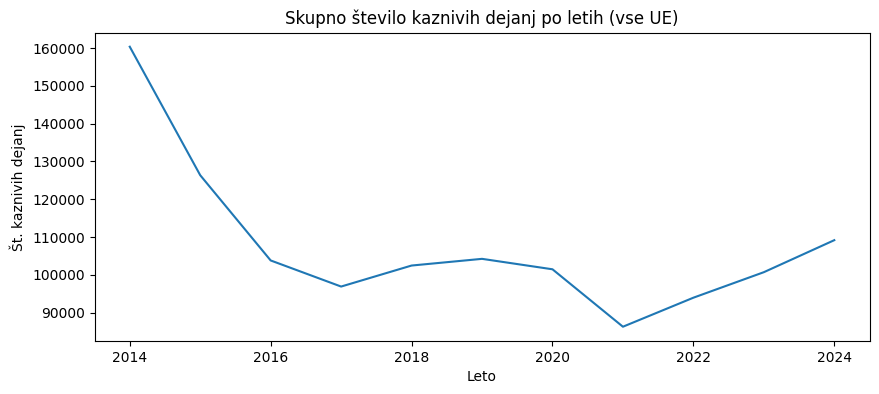

In [ ]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df_master, x="leto", y="st_kaznivih_dejanj",
             estimator="sum", errorbar=None)
plt.title("Skupno število kaznivih dejanj po letih (vse UE)")
plt.xlabel("Leto"); plt.ylabel("Št. kaznivih dejanj")
plt.show()

 Po padcu med 2014–2017 sledi nihanje in ponoven dvig po 2021; trend ni strogo monotoni, zato je smiselno modelirati časovni vpliv. Razlog za upad leta 2020 in 2021 poznamo, in sicer je to pandemija covid-19

####Top 10 UE po kaznivih dejanjih na 10k prebivalcev (zadnje leto)

Da identificiramo najbolj izpostavljene UE na prebivalca in kje bi bili ciljani ukrepi najbolj smiselni.

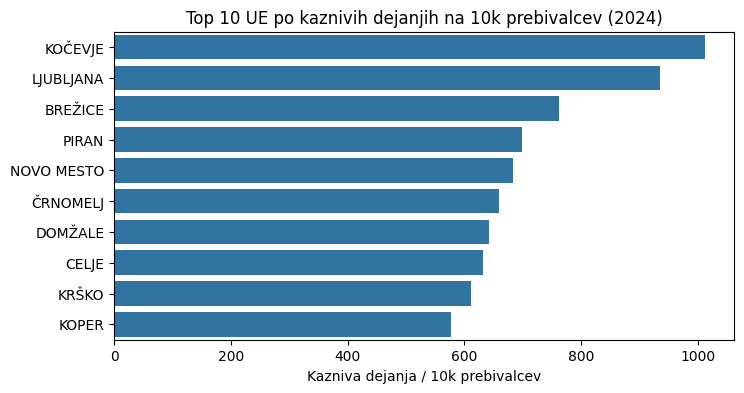

In [ ]:
zadnje_leto = df_master["leto"].max()
top_rate = (df_master[df_master.leto == zadnje_leto]
            .sort_values("kd_na_10k", ascending=False)
            .head(10))

plt.figure(figsize=(8,4))
sns.barplot(data=top_rate, y="Upravna_enota", x="kd_na_10k")
plt.title(f"Top 10 UE po kaznivih dejanjih na 10k prebivalcev ({zadnje_leto})")
plt.xlabel("Kazniva dejanja / 10k prebivalcev"); plt.ylabel("")
plt.show()

Nekaj UE močno izstopa (npr. Kočevje, Ljubljana) in je višje od ostalih; problem ni enakomerno porazdeljen.

#### Kazniva /10k vs. število tujcev in  št. delovno aktivnih

Da preverimo, ali večje število tujcev v UE pomeni več kaznivih dejanj na prebivalca in ali več delovno aktivnih pomeni več kaznivosti na prebivalca.

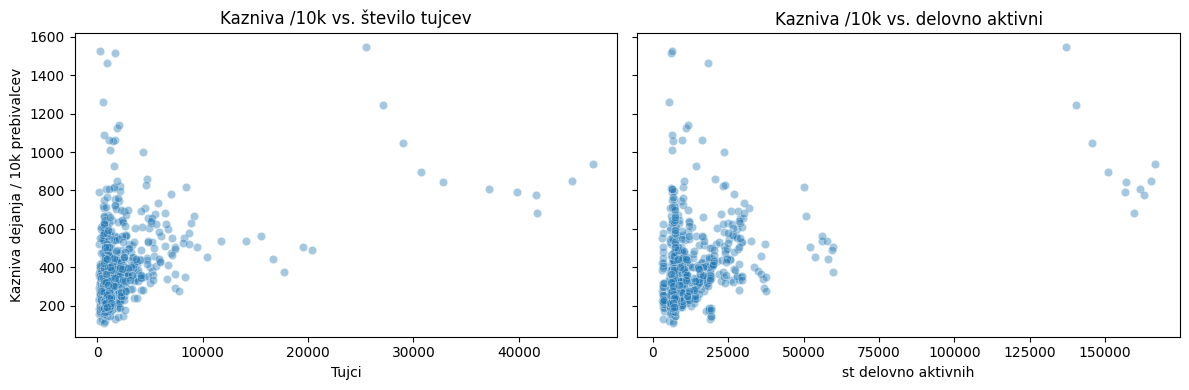

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4), sharey=True)
sns.scatterplot(data=df_master, x="Tujci", y="kd_na_10k", alpha=0.4, ax=axes[0])
axes[0].set_title("Kazniva /10k vs. število tujcev")
sns.scatterplot(data=df_master, x="st_delovno_aktivnih", y="kd_na_10k", alpha=0.4, ax=axes[1])
axes[1].set_title("Kazniva /10k vs. delovno aktivni")
for ax in axes:
    ax.set_xlabel(ax.get_xlabel().replace("_", " "))
axes[0].set_ylabel("Kazniva dejanja / 10k prebivalcev")
plt.tight_layout()
plt.show()

Ni jasne monotone povezave. Visoka kaznivost se pojavlja tudi v UE z malo tujcev; UE z največ tujci imajo srednje vrednosti kaznivosti, brez ekstremov.


Brez linearne povezave. Najvišje stopnje se pojavijo pri UE z nižjim/srednjim številom delovno aktivnih; največje UE po delovno aktivnih so v srednjem razponu kaznivosti.

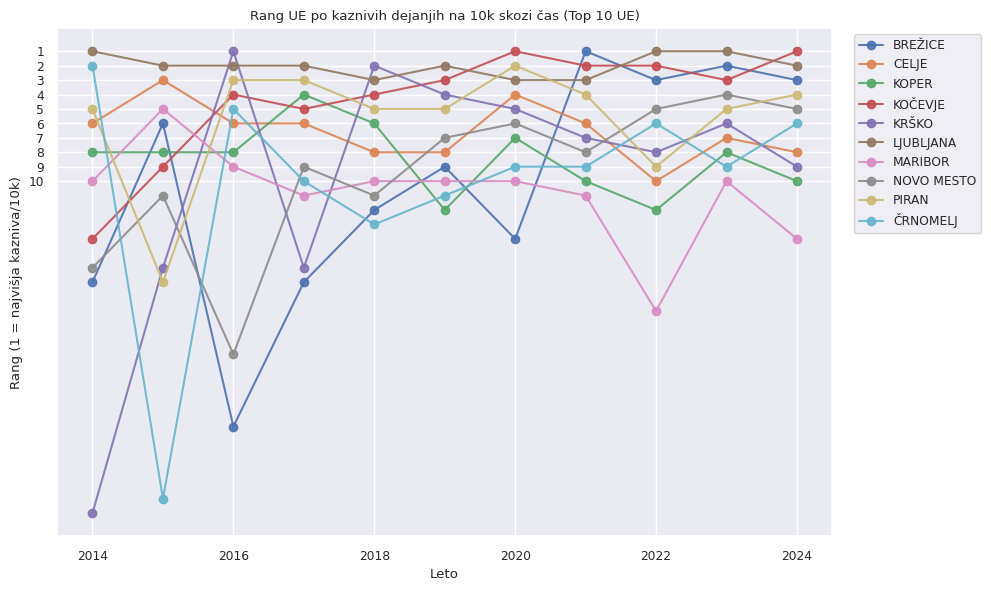

In [ ]:
# priprava rangov po letih
df_rank = (
    df_master
    .assign(kd_na_10k = df_master["st_kaznivih_dejanj"] / df_master["Prebivalstvo"] * 10_000)
    .sort_values(["leto", "kd_na_10k"], ascending=[True, False])
)
df_rank["rank"] = df_rank.groupby("leto")["kd_na_10k"].rank(method="first", ascending=False)

# izberi top N UE po povprečnem rangu (da graf ostane berljiv)
TOP_N = 10
top_ue = (
    df_rank.groupby("Upravna_enota")["rank"]
    .mean()
    .nsmallest(TOP_N)
    .index
)
df_plot = df_rank[df_rank["Upravna_enota"].isin(top_ue)]

plt.figure(figsize=(10,6))
for ue, sub in df_plot.groupby("Upravna_enota"):
    plt.plot(sub["leto"], sub["rank"], marker="o", label=ue, alpha=0.9)

plt.gca().invert_yaxis()  # rank 1 na vrh
plt.yticks(range(1, TOP_N+1))
plt.xlabel("Leto")
plt.ylabel(f"Rang (1 = najvišja kazniva/10k)")
plt.title(f"Rang UE po kaznivih dejanjih na 10k skozi čas (Top {TOP_N} UE)")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

#### Graf korelacij spremenljiv

Da hitro vidimo, kateri posamezni (linearni) faktorji imajo največ povezave s številom kaznivih dejanj.

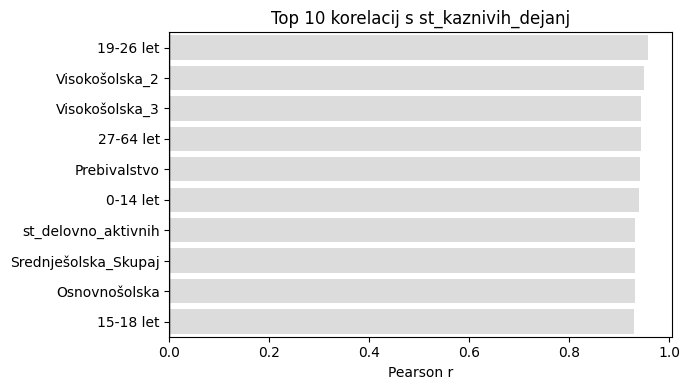

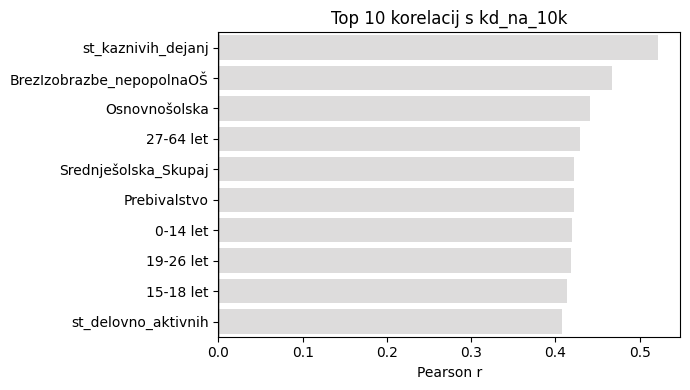

In [ ]:
target_cols = ["st_kaznivih_dejanj", "kd_na_10k"]
num_cols = [
    "st_kaznivih_dejanj", "kd_na_10k",
    "Prebivalstvo", "Tujci", "st_delovno_aktivnih",
    "BrezIzobrazbe_nepopolnaOŠ", "Osnovnošolska", "Srednješolska_Skupaj",
    "Visokošolska_1", "Visokošolska_2", "Visokošolska_3",
    "0-14 let", "15-18 let", "19-26 let", "27-64 let", "65 + let"
]

corr = df_master[num_cols].corr()

def plot_top_corr(target, n=10):
    series = corr[target].drop(target).dropna()
    top = series.reindex(series.abs().sort_values(ascending=False).head(n).index)
    plt.figure(figsize=(7,4))
    sns.barplot(x=top.values, y=top.index, palette="coolwarm",
                hue=(top.values>0), dodge=False, legend=False)
    plt.title(f"Top {n} korelacij s {target}")
    plt.xlabel("Pearson r"); plt.ylabel("")
    plt.axvline(0, color="k", lw=1)
    plt.tight_layout()
    plt.show()

plot_top_corr("st_kaznivih_dejanj", n=10)
plot_top_corr("kd_na_10k", n=10)

Korelacije so nizke do zmerne; noben feature ni močan samostojen napovednik. Najvišje korelacije imajo demografske/izobrazbene in starostne strukture, a linearno pojasnijo le del variabilnosti.

# Gručenje


In [ ]:
df_2024 = df_master[df_master["leto"] == 2024].copy()

# izračun per-capita/deležnih metrik
df_2024["kd_na_10k"]           = df_2024["st_kaznivih_dejanj"] / df_2024["Prebivalstvo"] * 10_000
df_2024["tujci_na_1k"]         = df_2024["Tujci"] / df_2024["Prebivalstvo"] * 1_000
df_2024["delovno_aktivni_rate"]= df_2024["st_delovno_aktivnih"] / df_2024["Prebivalstvo"]
df_2024["edu_low"]             = (df_2024["BrezIzobrazbe_nepopolnaOŠ"] + df_2024["Osnovnošolska"]) / df_2024["Prebivalstvo"]
df_2024["edu_mid"]             = df_2024["Srednješolska_Skupaj"] / df_2024["Prebivalstvo"]
df_2024["edu_high"]            = (df_2024["Visokošolska_1"] + df_2024["Visokošolska_2"] + df_2024["Visokošolska_3"]) / df_2024["Prebivalstvo"]
df_2024["age_0_14"]            = df_2024["0-14 let"] / df_2024["Prebivalstvo"]
df_2024["age_19_26"]           = df_2024["19-26 let"] / df_2024["Prebivalstvo"]
df_2024["age_27_64"]           = df_2024["27-64 let"] / df_2024["Prebivalstvo"]
df_2024["age_65p"]             = df_2024["65 + let"] / df_2024["Prebivalstvo"]

feat_cols = [
    "kd_na_10k", "tujci_na_1k", "delovno_aktivni_rate",
    "edu_low", "edu_mid", "edu_high",
    "age_0_14", "age_19_26", "age_27_64", "age_65p"
]

X = df_2024[feat_cols].copy()
X = X.fillna(X.median())  # varnostna mreža
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

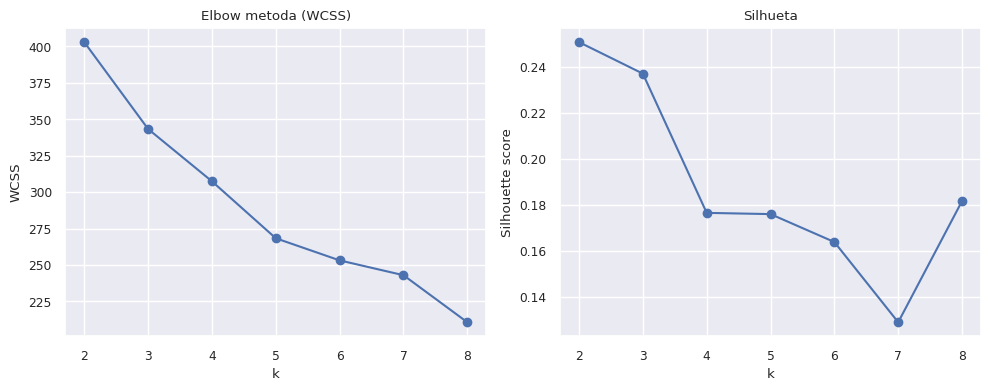

In [ ]:
wcss = []
sil_scores = []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)  # elbow
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(list(ks), wcss, marker="o")
ax[0].set_title("Elbow metoda (WCSS)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("WCSS")

ax[1].plot(list(ks), sil_scores, marker="o")
ax[1].set_title("Silhueta")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

In [ ]:
best_k = 3  # prilagodi glede na silhueto
km = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
df_2024["cluster"] = km.fit_predict(X_scaled)

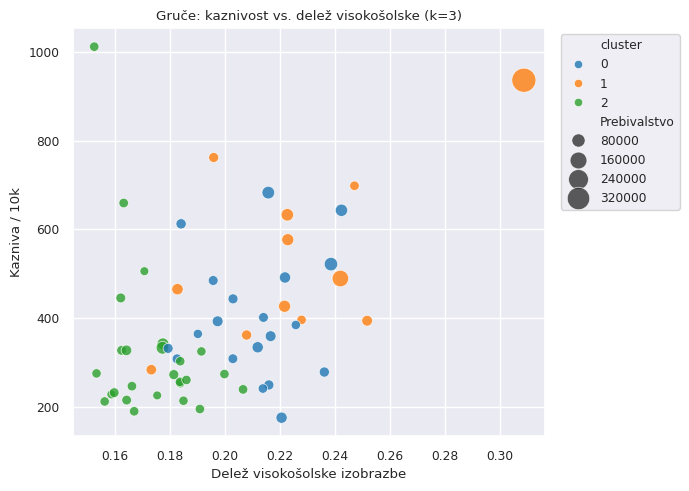

In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_2024,
    x="edu_high", y="kd_na_10k",
    hue="cluster", size="Prebivalstvo", sizes=(40, 300),
    palette="tab10", alpha=0.8
)
plt.title(f"Gruče: kaznivost vs. delež visokošolske (k={best_k})")
plt.xlabel("Delež visokošolske izobrazbe"); plt.ylabel("Kazniva / 10k")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

In [ ]:
df_2024["cluster"].value_counts().sort_index()

,count
cluster,
0,20
1,12
2,26


Zakaj gručenje? Da najdemo skupine UE, ki so si podobne po kaznivosti na prebivalca in socio-demografskih deležih, ter lažje opišemo tipologije (npr. “visoka kaznivost + nižja izobrazba”, “srednja kaznivost + višji delež tujcev”, …).
Smiselnost k: izbran k temelji na silhueti (preizkus k=2..8); k=4 daje ravnotežje med ločljivostjo in čitljivostjo.
Kaj smo izvedeli (primer obrazca):
Cluster 0: (pogled v profile) npr. višja kaznivost, višji delež mladih 19–26 in nižja visokošolska izobrazba.
Cluster 1: npr. srednja kaznivost, višji delež tujcev, večji prebivalstveni bazen.
Cluster 2: npr. nižja kaznivost, višji delež starejših, več srednješolske izobrazbe.
Cluster 3: npr. srednje–višja kaznivost, najvišji delež delovno aktivnih, mešan delež starosti.
Ločevanje gruč: Uporabi tabelo profile – primerjaj mediane kd_na_10k, deleže izobrazbe in starostne strukture. Pogled na value_counts() pove, koliko UE pade v vsak cluster, scatter graf pa pokaže razlike v kaznivosti in deležu tujcev (ter velikost populacije).

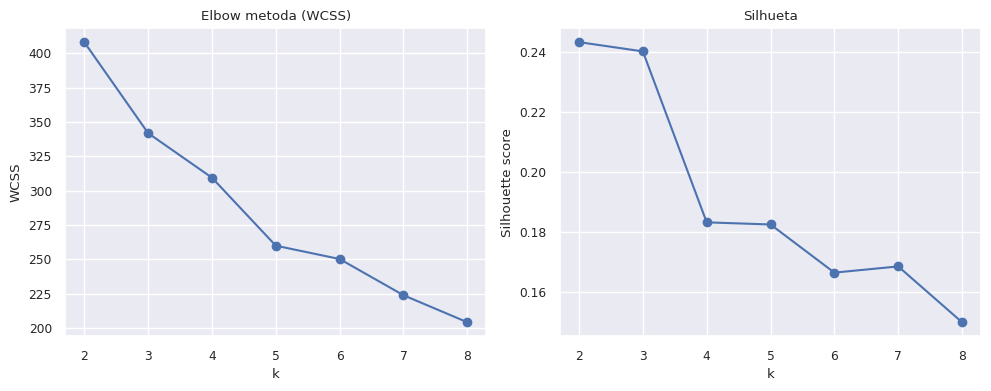

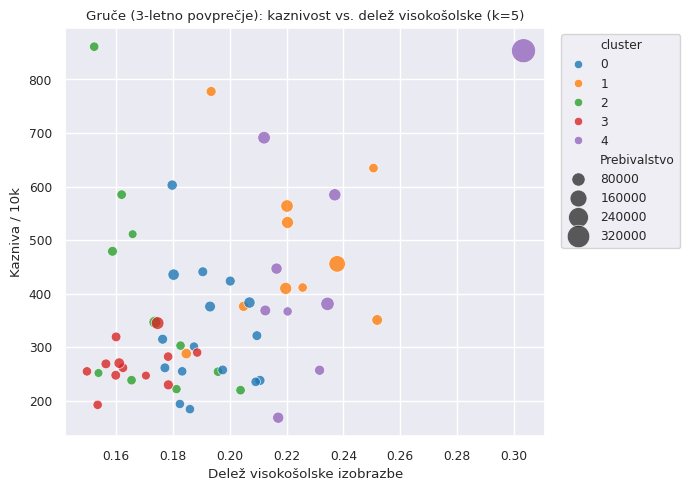

/tmp/ipython-input-863333227.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_3y_mean, x="cluster", y="kd_na_10k", palette="tab10")


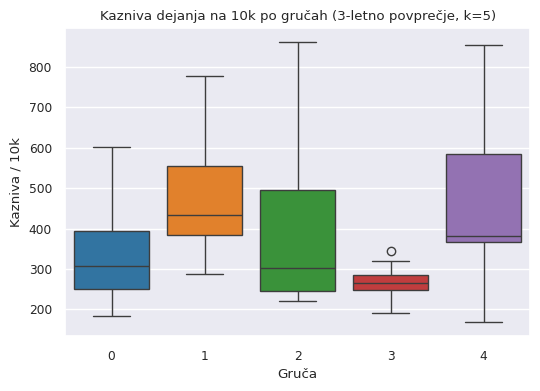

,kd_na_10k,tujci_na_1k,delovno_aktivni_rate,edu_low,edu_mid,edu_high,age_0_14,age_19_26,age_27_64,age_65p,Prebivalstvo
cluster,,,,,,,,,,,
0,307.899,70.826,0.436,0.202,0.449,0.189,0.154,0.070,0.523,0.209,21983.167
1,433.419,127.354,0.419,0.189,0.455,0.220,0.140,0.069,0.515,0.237,33894.667
2,302.819,65.534,0.402,0.233,0.469,0.166,0.132,0.062,0.514,0.253,16609.000
3,265.030,52.074,0.392,0.210,0.488,0.162,0.140,0.069,0.527,0.232,18793.167
4,380.785,85.635,0.454,0.179,0.424,0.220,0.170,0.082,0.516,0.191,43589.667


,count
cluster,
0,16
1,10
2,11
3,12
4,9


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1) Priprava 3-letnih povprečij (2022–2024)
df_3y = df_master[df_master["leto"].between(2022, 2024)].copy()

df_3y["kd_na_10k"]            = df_3y["st_kaznivih_dejanj"] / df_3y["Prebivalstvo"] * 10_000
df_3y["tujci_na_1k"]          = df_3y["Tujci"] / df_3y["Prebivalstvo"] * 1_000
df_3y["delovno_aktivni_rate"] = df_3y["st_delovno_aktivnih"] / df_3y["Prebivalstvo"]
df_3y["edu_low"]   = (df_3y["BrezIzobrazbe_nepopolnaOŠ"] + df_3y["Osnovnošolska"]) / df_3y["Prebivalstvo"]
df_3y["edu_mid"]   = df_3y["Srednješolska_Skupaj"] / df_3y["Prebivalstvo"]
df_3y["edu_high"]  = (df_3y["Visokošolska_1"] + df_3y["Visokošolska_2"] + df_3y["Visokošolska_3"]) / df_3y["Prebivalstvo"]
df_3y["age_0_14"]  = df_3y["0-14 let"] / df_3y["Prebivalstvo"]
df_3y["age_19_26"] = df_3y["19-26 let"] / df_3y["Prebivalstvo"]
df_3y["age_27_64"] = df_3y["27-64 let"] / df_3y["Prebivalstvo"]
df_3y["age_65p"]   = df_3y["65 + let"] / df_3y["Prebivalstvo"]

agg_cols = [
    "kd_na_10k", "tujci_na_1k", "delovno_aktivni_rate",
    "edu_low", "edu_mid", "edu_high",
    "age_0_14", "age_19_26", "age_27_64", "age_65p",
    "Prebivalstvo"
]

df_3y_mean = (
    df_3y.groupby("Upravna_enota")[agg_cols]
    .mean()
    .reset_index()
)

feat_cols = [
    "kd_na_10k", "tujci_na_1k", "delovno_aktivni_rate",
    "edu_low", "edu_mid", "edu_high",
    "age_0_14", "age_19_26", "age_27_64", "age_65p"
]

X = df_3y_mean[feat_cols].copy().fillna(df_3y_mean[feat_cols].median())
X_scaled = StandardScaler().fit_transform(X)

# 2) Elbow + silhueta (k=2..8)
wcss = []
sil_scores = []
ks = range(2, 9)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(list(ks), wcss, marker="o")
ax[0].set_title("Elbow metoda (WCSS)")
ax[0].set_xlabel("k"); ax[0].set_ylabel("WCSS")

ax[1].plot(list(ks), sil_scores, marker="o")
ax[1].set_title("Silhueta")
ax[1].set_xlabel("k"); ax[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.show()

# 3) Izberi k (npr. k=3, če je silhueta najvišja ali dober kompromis)
best_3 = 5  # prilagodi glede na grafe
km = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
df_3y_mean["cluster"] = km.fit_predict(X_scaled)

# 4) Vizualizacija 1: scatter kazniva/10k vs. delež visokošolske (barva=cluster, velikost=Prebivalstvo)
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df_3y_mean,
    x="edu_high", y="kd_na_10k",
    hue="cluster", size="Prebivalstvo", sizes=(40, 300),
    palette="tab10", alpha=0.8
)
plt.title(f"Gruče (3-letno povprečje): kaznivost vs. delež visokošolske (k={best_k})")
plt.xlabel("Delež visokošolske izobrazbe"); plt.ylabel("Kazniva / 10k")
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.show()

# 5) Vizualizacija 2: boxplot kazniva/10k po gručah
plt.figure(figsize=(6,4))
sns.boxplot(data=df_3y_mean, x="cluster", y="kd_na_10k", palette="tab10")
plt.title(f"Kazniva dejanja na 10k po gručah (3-letno povprečje, k={best_k})")
plt.xlabel("Gruča"); plt.ylabel("Kazniva / 10k")
plt.show()

# 6) Profil gruč (mediane)
profile = (
    df_3y_mean
    .groupby("cluster")[feat_cols + ["Prebivalstvo"]]
    .median()
    .sort_index()
)
display(profile.round(3))

# 7) Število UE v gručah
display(df_3y_mean["cluster"].value_counts().sort_index())

#KLASIFIKACIJA

#REGRESIJA


In [ ]:
df = df_master.copy()
df["kd_na_10k"]            = df["st_kaznivih_dejanj"] / df["Prebivalstvo"] * 10_000
df["tujci_na_1k"]          = df["Tujci"] / df["Prebivalstvo"] * 1_000
df["delovno_aktivni_rate"] = df["st_delovno_aktivnih"] / df["Prebivalstvo"]
df["edu_low"]   = (df["BrezIzobrazbe_nepopolnaOŠ"] + df["Osnovnošolska"]) / df["Prebivalstvo"]
df["edu_mid"]   = df["Srednješolska_Skupaj"] / df["Prebivalstvo"]
df["edu_high"]  = (df["Visokošolska_1"] + df["Visokošolska_2"] + df["Visokošolska_3"]) / df["Prebivalstvo"]
df["age_0_14"]  = df["0-14 let"] / df["Prebivalstvo"]
df["age_19_26"] = df["19-26 let"] / df["Prebivalstvo"]
df["age_27_64"] = df["27-64 let"] / df["Prebivalstvo"]
df["age_65p"]   = df["65 + let"] / df["Prebivalstvo"]
df["leto_num"]  = df["leto"]  # kot numerični trend

feat_cols = [
    "tujci_na_1k", "delovno_aktivni_rate",
    "edu_low", "edu_mid", "edu_high",
    "age_0_14", "age_19_26", "age_27_64", "age_65p",
    "leto_num"
]
target_col = "kd_na_10k"

In [ ]:
train = df[df.leto <= 2023].copy()
test  = df[df.leto == 2024].copy()

X_train = train[feat_cols].fillna(train[feat_cols].median())
y_train = train[target_col]
X_test  = test[feat_cols].fillna(train[feat_cols].median())  # mediana iz train
y_test  = test[target_col]  # za eval, pri pravi napovedi 2024 ne bi gledali y_test

In [ ]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

In [ ]:
models = {
    "linreg": ("scaled", LinearRegression()),
    "rf":     ("raw",    RandomForestRegressor(n_estimators=400, random_state=42)),
    "gbr":    ("raw",    GradientBoostingRegressor(random_state=42))
}

def eval_reg(name, use_scaled, model):
    if use_scaled:
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    mae  = mean_absolute_error(y_test, preds)
    mse  = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, preds)
    print(f"{name}: MAE={mae:.1f}, RMSE={rmse:.1f}, R2={r2:.3f}")
    return preds

preds_dict = {}
for name, (mode, model) in models.items():
    preds = eval_reg(name, use_scaled=(mode=="scaled"), model=model)
    preds_dict[name] = preds

linreg: MAE=114.1, RMSE=173.1, R2=0.088
rf: MAE=84.4, RMSE=112.8, R2=0.612
gbr: MAE=85.5, RMSE=113.9, R2=0.605


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "n_estimators": [200, 400, 600],
    "max_depth": [None, 10, 20],
    "min_samples_leaf": [1, 2, 4]
}
rf_gs = GridSearchCV(RandomForestRegressor(random_state=42),
                     param_grid_rf,
                     cv=3,
                     scoring="neg_mean_absolute_error",
                     n_jobs=-1)
rf_gs.fit(X_train, y_train)
print("Best RF params:", rf_gs.best_params_)

# Ponovna evalvacija z best RF
best_rf = rf_gs.best_estimator_
preds_best_rf = best_rf.predict(X_test)
mae  = mean_absolute_error(y_test, preds_best_rf)
mse = mean_squared_error(y_test, preds_best_rf)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, preds_best_rf)
print(f"best_rf: MAE={mae:.1f}, RMSE={rmse:.1f}, R2={r2:.3f}")

Best RF params: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 400}
best_rf: MAE=51.1, RMSE=68.3, R2=0.858


In [ ]:
test["pred_kd_na_10k"] = preds_best_rf
test[["Upravna_enota", "leto", "kd_na_10k", "pred_kd_na_10k"]].head()

,Upravna_enota,leto,kd_na_10k,pred_kd_na_10k
580,AJDOVŠČINA,2024,248.914392,240.144195
581,BREŽICE,2024,761.900867,723.066474
582,CELJE,2024,632.722170,545.512358
583,CERKNICA,2024,240.821627,236.841221
584,DOMŽALE,2024,642.857143,517.556675


In [ ]:
import pandas as pd, numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# --- 1) Priprava inženiringa ---
df = df_master.copy().sort_values(["Upravna_enota", "leto"])

# osnovne metrike
df["kd_na_10k"] = df["st_kaznivih_dejanj"] / df["Prebivalstvo"] * 10_000
df["tujci_na_1k"] = df["Tujci"] / df["Prebivalstvo"] * 1_000
df["delovno_aktivni_rate"] = df["st_delovno_aktivnih"] / df["Prebivalstvo"]
df["edu_low"]  = (df["BrezIzobrazbe_nepopolnaOŠ"] + df["Osnovnošolska"]) / df["Prebivalstvo"]
df["edu_mid"]  = df["Srednješolska_Skupaj"] / df["Prebivalstvo"]
df["edu_high"] = (df["Visokošolska_1"] + df["Visokošolska_2"] + df["Visokošolska_3"]) / df["Prebivalstvo"]
df["age_0_14"]  = df["0-14 let"] / df["Prebivalstvo"]
df["age_19_26"] = df["19-26 let"] / df["Prebivalstvo"]
df["age_27_64"] = df["27-64 let"] / df["Prebivalstvo"]
df["age_65p"]   = df["65 + let"] / df["Prebivalstvo"]
df["leto_num"]  = df["leto"]

# lag po UE
df["kd_na_10k_lag1"] = df.groupby("Upravna_enota")["kd_na_10k"].shift(1)
df["tujci_na_1k_lag1"] = df.groupby("Upravna_enota")["tujci_na_1k"].shift(1)
df["delovno_aktivni_rate_lag1"] = df.groupby("Upravna_enota")["delovno_aktivni_rate"].shift(1)

# delta za exogene (ok)
df["delta_tujci"] = df["tujci_na_1k"] - df["tujci_na_1k_lag1"]
df["delta_delovno"] = df["delovno_aktivni_rate"] - df["delovno_aktivni_rate_lag1"]

# rolling na preteklih letih (shift pred rolling)
df["kd_na_10k_roll3_lag"] = (
    df.groupby("Upravna_enota")["kd_na_10k"]
      .transform(lambda s: s.shift(1).rolling(3, min_periods=1).mean())
)

feat_cols = [
    "tujci_na_1k", "delovno_aktivni_rate",
    "edu_low", "edu_mid", "edu_high",
    "age_0_14", "age_19_26", "age_27_64", "age_65p",
    "leto_num",
    "kd_na_10k_lag1",
    "tujci_na_1k_lag1", "delta_tujci",
    "delovno_aktivni_rate_lag1", "delta_delovno",
    "kd_na_10k_roll3_lag"
]
target_col = "kd_na_10k"

# --- 2) Časovni split ---
train = df[df.leto <= 2023].copy()
test  = df[df.leto == 2024].copy()

X_train = train[feat_cols].fillna(train[feat_cols].median())
X_test  = test[feat_cols].fillna(train[feat_cols].median())
y_train = train[target_col].values
y_test  = test[target_col].values

# --- 3) Standardizacija za modele, ki to rabijo ---
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# --- 4) Modeli + eval ---
models = {
    "linreg": ("scaled", LinearRegression()),
    "rf":     ("raw",    RandomForestRegressor(n_estimators=500, random_state=42)),
    "gbr":    ("raw",    GradientBoostingRegressor(random_state=42))
}

def eval_reg(name, use_scaled, model):
    if use_scaled:
        model.fit(X_train_s, y_train)
        preds = model.predict(X_test_s)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f"{name:6s} | MAE={mae:8.1f} | RMSE={rmse:8.1f} | R2={r2:6.3f}")
    return preds

preds_dict = {}
for name, (mode, model) in models.items():
    preds = eval_reg(name, use_scaled=(mode=="scaled"), model=model)
    preds_dict[name] = preds

test["pred_kd_na_10k"] = preds_dict["rf"]  # ali izberi najboljšega
test[["Upravna_enota", "leto", "kd_na_10k", "pred_kd_na_10k"]].head()

linreg | MAE=    72.4 | RMSE=   107.6 | R2= 0.647
rf     | MAE=    53.2 | RMSE=    79.4 | R2= 0.808
gbr    | MAE=    56.9 | RMSE=    77.0 | R2= 0.820


,Upravna_enota,leto,kd_na_10k,pred_kd_na_10k
580,AJDOVŠČINA,2024,248.914392,241.950517
581,BREŽICE,2024,761.900867,748.447983
582,CELJE,2024,632.722170,548.682330
583,CERKNICA,2024,240.821627,246.920850
584,DOMŽALE,2024,642.857143,561.394687
